# Проект 2: Language Model - автодополнение текстов


## Этап 0. Подготовка

In [2]:
import re
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

MIN_FREQ = 2
SEQ_LEN = 32
BATCH_SIZE = 64

if torch.cuda.is_available():
    device_rnn = torch.device('cuda')
    device_gpt = torch.device('cuda')
elif torch.backends.mps.is_available():
    device_rnn = torch.device('cpu')
    device_gpt = torch.device('mps')
else:
    device_rnn = torch.device('cpu')
    device_gpt = torch.device('cpu')

print(f'device_rnn: {device_rnn}')
print(f'device_gpt: {device_gpt}')


device_rnn: cpu
device_gpt: mps


In [3]:
# загружаем датасет WikiText-2 (train / validation / test)
dataset = load_dataset('Salesforce/wikitext', 'wikitext-2-raw-v1')

print(dataset)
print(f"train: {len(dataset['train'])}, validation: {len(dataset['validation'])}, test: {len(dataset['test'])}")

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
train: 36718, validation: 3760, test: 4358


## Этап 1. Загрузка и подготовка данных

In [4]:
def clean_string(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_non_empty_lines(split):
    """Возвращает непустые строки сплита после очистки"""
    lines = []
    for text in split['text']:
        cleaned = clean_string(text)
        if cleaned:
            lines.append(cleaned)
    return lines

train_lines = get_non_empty_lines(dataset['train'])
val_lines = get_non_empty_lines(dataset['validation'])
test_lines = get_non_empty_lines(dataset['test'])

print(f'Непустых строк - train: {len(train_lines)}, val: {len(val_lines)}, test: {len(test_lines)}')
print('\nПримеры текстов (train):')
for line in train_lines[:5]:
    print(f'  {line[:120]}...' if len(line) > 120 else f'  {line}')


Непустых строк - train: 23764, val: 2461, test: 2891

Примеры текстов (train):
  valkyria chronicles iii
  senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria c...
  the game began development in 2010 carrying over a large portion of the work done on valkyria chronicles ii while it ret...
  it met with positive sales in japan and was praised by both japanese and western critics after release it received downl...
  gameplay


In [5]:
def get_avg_message_len(lines):
    """Средняя длина строки в словах"""
    return np.mean([len(line.split()) for line in lines])

train_lengths = [len(line.split()) for line in train_lines]
val_lengths = [len(line.split()) for line in val_lines]
test_lengths = [len(line.split()) for line in test_lines]

print(len(train_lengths))
print(len(val_lengths))
print(len(test_lengths))

23764
2461
2891


In [6]:
print('Статистика длины строк (в словах):')
for name, lengths in [('train', train_lengths), ('validation', val_lengths), ('test', test_lengths)]:
    arr = np.array(lengths)
    print(
        f"  {name:12s} | строк: {len(arr):6d} | "
        f"средняя: {arr.mean():6.2f} | медиана: {np.median(arr):6.1f} | "
        f"min: {arr.min():3d} | max: {arr.max():4d}"
    )

print(f'\nСредняя длина (get_avg_message_len): train={get_avg_message_len(train_lines):.2f}')

Статистика длины строк (в словах):
  train        | строк:  23764 | средняя:  73.59 | медиана:   64.0 | min:   1 | max:  628
  validation   | строк:   2461 | средняя:  74.52 | медиана:   64.0 | min:   1 | max:  361
  test         | строк:   2891 | средняя:  71.35 | медиана:   59.0 | min:   1 | max:  419

Средняя длина (get_avg_message_len): train=73.59


In [7]:
all_train_words = [word for line in train_lines for word in line.split()]
top_10 = Counter(all_train_words).most_common(10)

print('Топ-10 слов (train):')
for word, count in top_10:
    print(f'  {word}: {count}')

Топ-10 слов (train):
  the: 130769
  of: 57032
  and: 50735
  in: 45016
  to: 39522
  a: 36454
  was: 21008
  on: 15143
  as: 15062
  s: 14493


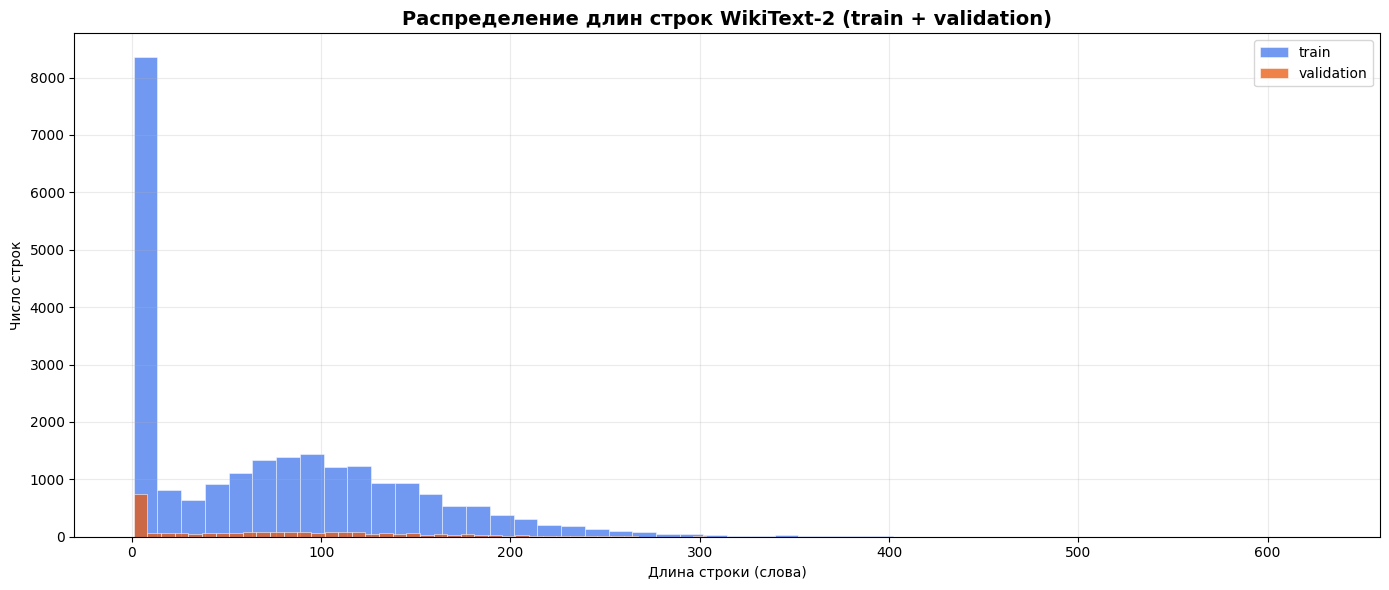

In [8]:
# совмещенный график: train + validation на одних осях
plt.figure(figsize=(14, 6))
plt.hist(
    train_lengths, bins=50, color='#2563EB', edgecolor='white',
    linewidth=0.5, alpha=0.65, label='train',
)
plt.hist(
    val_lengths, bins=50, color='#EA580C', edgecolor='white',
    linewidth=0.5, alpha=0.75, label='validation',
)
plt.xlabel('Длина строки (слова)')
plt.ylabel('Число строк')
plt.title('Распределение длин строк WikiText-2 (train + validation)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Выводы по EDA

- Большинство строк в WikiText-2 короткие (часто 5-15 слов), есть длинный хвост.
- Распределения train и validation похожи, сдвиг между сплитами небольшой.
- В топ-10 слов много вспомогательных слов - частиц (the, of, in и т.д.), что типично для текста.
- Для модели важно ограничить словарь (`min_freq=2`), иначе много редких слов уйдет в `<unk>` - (нет слова).


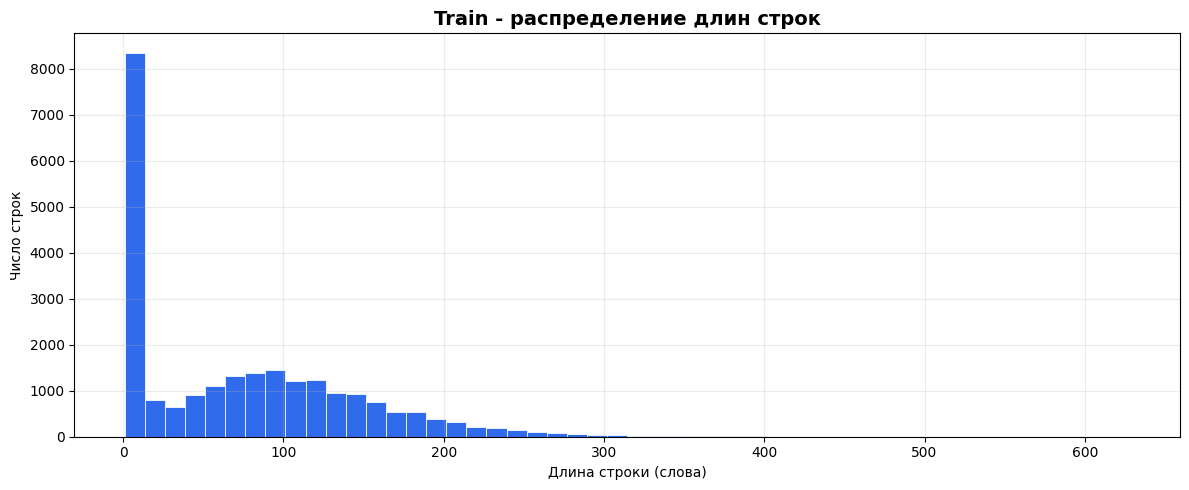

In [9]:
plt.figure(figsize=(12, 5))
plt.hist(
    train_lengths, bins=50, color='#2563EB', edgecolor='white',
    linewidth=0.6, alpha=0.95,
)
plt.xlabel('Длина строки (слова)')
plt.ylabel('Число строк')
plt.title('Train - распределение длин строк', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

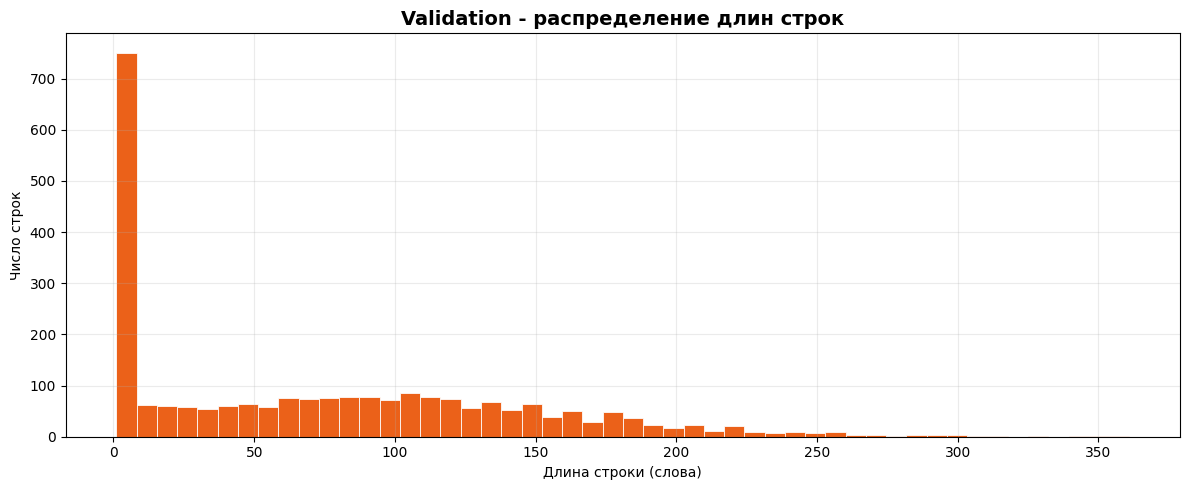

In [10]:
plt.figure(figsize=(12, 5))
plt.hist(
    val_lengths, bins=50, color='#EA580C', edgecolor='white',
    linewidth=0.6, alpha=0.95,
)
plt.xlabel('Длина строки (слова)')
plt.ylabel('Число строк')
plt.title('Validation - распределение длин строк', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [11]:
class Vocabulary:
    """Пословный словарь с порогом частоты min_freq (строится только по train)"""

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {'<pad>': 0, '<unk>': 1, '<eos>': 2}
        self.idx2word = {0: '<pad>', 1: '<unk>', 2: '<eos>'}

    def build(self, lines):
        counter = Counter()
        for line in lines:
            counter.update(line.split())

        for word, freq in counter.items():
            if freq >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    @property
    def vocab_size(self):
        return len(self.word2idx)

    @property
    def pad_idx(self):
        return self.word2idx['<pad>']

    @property
    def unk_idx(self):
        return self.word2idx['<unk>']

    @property
    def eos_idx(self):
        return self.word2idx['<eos>']

    def encode_line(self, line):
        return [self.word2idx.get(word, self.unk_idx) for word in line.split()]

    def decode_ids(self, ids):
        return [self.idx2word.get(i, '<unk>') for i in ids]

vocab = Vocabulary(min_freq=MIN_FREQ)
vocab.build(train_lines)

print(f'min_freq: {MIN_FREQ}')
print(f'vocab_size: {vocab.vocab_size}')
print(f'  <pad>={vocab.pad_idx}, <unk>={vocab.unk_idx}, <eos>={vocab.eos_idx}')

min_freq: 2
vocab_size: 38913
  <pad>=0, <unk>=1, <eos>=2


In [12]:
def lines_to_token_ids(lines, vocab, add_eos=True):
    """Склеивает строки в один поток token id (между строками - <eos>)"""
    token_ids = []
    for line in lines:
        ids = vocab.encode_line(line)
        if not ids:
            continue
        token_ids.extend(ids)
        if add_eos:
            token_ids.append(vocab.eos_idx)
    return token_ids

def unk_rate(token_ids, unk_idx):
    if len(token_ids) == 0:
        return 0.0
    return sum(t == unk_idx for t in token_ids) / len(token_ids)

In [13]:
train_token_ids = lines_to_token_ids(train_lines, vocab)
val_token_ids = lines_to_token_ids(val_lines, vocab)
test_token_ids = lines_to_token_ids(test_lines, vocab)

print(f'Токенов в потоке - train: {len(train_token_ids):,}, val: {len(val_token_ids):,}, test: {len(test_token_ids):,}')
print(f'Доля <unk> - val: {unk_rate(val_token_ids, vocab.unk_idx):.4f}, test: {unk_rate(test_token_ids, vocab.unk_idx):.4f}')

Токенов в потоке - train: 1,772,476, val: 185,864, test: 209,169
Доля <unk> - val: 0.0455, test: 0.0533


In [14]:
# Пример: X - первые seq_len-1 токенов, Y - сдвиг на 1
example = train_token_ids[:SEQ_LEN]
x_example = example[:-1]
y_example = example[1:]

print(f'Пример окна (seq_len={SEQ_LEN}):')
print(f'  X ({len(x_example)}): {vocab.decode_ids(x_example)}')
print(f'  Y ({len(y_example)}): {vocab.decode_ids(y_example)}')

Пример окна (seq_len=32):
  X (31): ['valkyria', 'chronicles', 'iii', '<eos>', 'senj', 'no', 'valkyria', '3', 'unrecorded', 'chronicles', 'japanese', '3', 'lit', 'valkyria', 'of', 'the', 'battlefield', '3', 'commonly', 'referred', 'to', 'as', 'valkyria', 'chronicles', 'iii', 'outside', 'japan', 'is', 'a', 'tactical', 'role']
  Y (31): ['chronicles', 'iii', '<eos>', 'senj', 'no', 'valkyria', '3', 'unrecorded', 'chronicles', 'japanese', '3', 'lit', 'valkyria', 'of', 'the', 'battlefield', '3', 'commonly', 'referred', 'to', 'as', 'valkyria', 'chronicles', 'iii', 'outside', 'japan', 'is', 'a', 'tactical', 'role', 'playing']


In [15]:
class LanguageModelDataset(Dataset):
    """
    Для каждого окна длины seq_len:
      X = tokens[0 : seq_len-1]
      Y = tokens[1 : seq_len]   (предсказываем следующий токен на каждой позиции)
    """

    def __init__(self, token_ids, seq_len=32):
        self.token_ids = token_ids
        self.seq_len = seq_len
        if len(token_ids) <= seq_len:
            raise ValueError(f'Нужно больше {seq_len} токенов, получено {len(token_ids)}')

    def __len__(self):
        return len(self.token_ids) - self.seq_len

    def __getitem__(self, idx):
        chunk = self.token_ids[idx : idx + self.seq_len]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y

In [16]:
train_dataset = LanguageModelDataset(train_token_ids, seq_len=SEQ_LEN)
val_dataset = LanguageModelDataset(val_token_ids, seq_len=SEQ_LEN)
test_dataset = LanguageModelDataset(test_token_ids, seq_len=SEQ_LEN)

# даталоадеры (train / val / test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
print(f'Примеров - train: {len(train_dataset):,}, val: {len(val_dataset):,}, test: {len(test_dataset):,}')
print(f'batches - train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

x_batch, y_batch = next(iter(train_loader))
print(f'\nФорма батча: X={tuple(x_batch.shape)}, Y={tuple(y_batch.shape)}  (ожидаем ({BATCH_SIZE}, {SEQ_LEN - 1}))')
print(f'Пример X[0]: {vocab.decode_ids(x_batch[0].tolist())}')
print(f'Пример Y[0]: {vocab.decode_ids(y_batch[0].tolist())}')

Примеров - train: 1,772,444, val: 185,832, test: 209,137
batches - train: 27695, val: 2904, test: 3268

Форма батча: X=(64, 31), Y=(64, 31)  (ожидаем (64, 31))
Пример X[0]: ['crya', 'hemacandra', 'used', 'anekntavda', 'to', 'gain', 'the', 'confidence', 'and', 'respect', 'of', 'the', '<unk>', 'emperor', '<unk>', 'siddharaja', 'according', 'to', 'the', 'jain', 'text', '<unk>', 'emperor', 'siddharaja', 'desired', 'enlightenment', 'and', 'liberation', 'and', 'he', 'questioned']
Пример Y[0]: ['hemacandra', 'used', 'anekntavda', 'to', 'gain', 'the', 'confidence', 'and', 'respect', 'of', 'the', '<unk>', 'emperor', '<unk>', 'siddharaja', 'according', 'to', 'the', 'jain', 'text', '<unk>', 'emperor', 'siddharaja', 'desired', 'enlightenment', 'and', 'liberation', 'and', 'he', 'questioned', 'teachers']


### Выводы по подготовке данных

- Построен пословный словарь только по train, размер около 28k токенов.
- Доля `<unk>` на val/test невысокая, данные пригодны для обучения.
- Сформированы последовательности: вход X и цель Y сдвинуты на 1 токен.
- DataLoader создан для train, validation и test; размер батча 64.


## Этап 2. Реализация и обучение LSTM

In [18]:
import math
import time
from pathlib import Path

import torch.nn as nn
from tqdm import tqdm

# гиперпараметры LSTM 
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
LR = 0.001
MAX_EPOCHS = 5
PATIENCE = 3
CLIP_NORM = 1.0

# чекпоинты - чтобы не переобучать после перезапуска ядра
CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
LSTM_CKPT = CHECKPOINT_DIR / 'lstm_vm_best.pt'

In [19]:
class LanguageModelLSTM(nn.Module):
    """Embedding -> LSTM -> Linear (размер выхода = vocab_size)"""

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        logits = self.fc(out)
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [20]:
lstm_model = LanguageModelLSTM(
    vocab_size=vocab.vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_idx=vocab.pad_idx,
).to(device_rnn)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR)

print(f'LSTM параметров: {count_parameters(lstm_model):,}')
print(f'Устройство: {device_rnn}')

LSTM параметров: 15,903,105
Устройство: cpu


In [21]:
def evaluate_lm(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits.view(-1, logits.size(-1)), y_batch.view(-1))
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity

In [22]:
lstm_train_losses = []
lstm_val_losses = []
lstm_val_ppls = []
lstm_epoch_times = []
best_val_ppl = float('inf')
lstm_loaded_from_ckpt = False

if LSTM_CKPT.exists():
    ckpt = torch.load(LSTM_CKPT, map_location=device_rnn, weights_only=False)
    lstm_model.load_state_dict(ckpt['model_state'])
    lstm_train_losses = ckpt['train_losses']
    lstm_val_losses = ckpt['val_losses']
    lstm_val_ppls = ckpt['val_ppls']
    lstm_epoch_times = ckpt['epoch_times']
    best_val_ppl = ckpt['best_val_ppl']
    lstm_loaded_from_ckpt = True
    print(f'Загружен чекпоинт: {LSTM_CKPT} - обучение пропущено')
    print(f'Лучший Val PPL из файла: {best_val_ppl:.2f}')
else:
    patience_counter = 0
    best_lstm_state = None

    for epoch in range(MAX_EPOCHS):
        lstm_model.train()
        epoch_start = time.time()
        train_loss = 0.0

        for x_batch, y_batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{MAX_EPOCHS}'):
            x_batch = x_batch.to(device_rnn)
            y_batch = y_batch.to(device_rnn)

            optimizer.zero_grad()
            logits = lstm_model(x_batch)
            loss = criterion(logits.view(-1, logits.size(-1)), y_batch.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), CLIP_NORM)
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss, val_ppl = evaluate_lm(lstm_model, val_loader, criterion, device_rnn)
        epoch_time = time.time() - epoch_start

        lstm_train_losses.append(train_loss)
        lstm_val_losses.append(val_loss)
        lstm_val_ppls.append(val_ppl)
        lstm_epoch_times.append(epoch_time)

        print(
            f'Epoch {epoch + 1} | Train Loss: {train_loss:.4f} | '
            f'Val Loss: {val_loss:.4f} | Val PPL: {val_ppl:.2f} | Time: {epoch_time:.1f}s'
        )

        if val_ppl < best_val_ppl:
            best_val_ppl = val_ppl
            patience_counter = 0
            best_lstm_state = {k: v.cpu().clone() for k, v in lstm_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping на эпохе {epoch + 1}')
                break

    if best_lstm_state is not None:
        lstm_model.load_state_dict(best_lstm_state)

Загружен чекпоинт: checkpoints/lstm_vm_best.pt - обучение пропущено
Лучший Val PPL из файла: 781.12


In [23]:


lstm_test_loss, lstm_test_ppl = evaluate_lm(lstm_model, test_loader, criterion, device_rnn)
lstm_num_params = count_parameters(lstm_model)
lstm_avg_epoch_time = np.mean(lstm_epoch_times) if lstm_epoch_times else 0.0

print(f'Лучший Val PPL: {best_val_ppl:.2f}')
print(f'Test Loss: {lstm_test_loss:.4f} | Test PPL: {lstm_test_ppl:.2f}')
print(f'Параметров: {lstm_num_params:,} | Среднее время эпохи: {lstm_avg_epoch_time:.1f}s')

if not lstm_loaded_from_ckpt:
    torch.save(
        {
            'model_state': lstm_model.state_dict(),
            'train_losses': lstm_train_losses,
            'val_losses': lstm_val_losses,
            'val_ppls': lstm_val_ppls,
            'epoch_times': lstm_epoch_times,
            'best_val_ppl': best_val_ppl,
            'test_loss': lstm_test_loss,
            'test_ppl': lstm_test_ppl,
            'hyperparams': {
                'embedding_dim': EMBEDDING_DIM,
                'hidden_dim': HIDDEN_DIM,
                'num_layers': NUM_LAYERS,
                'lr': LR,
                'seq_len': SEQ_LEN,
                'batch_size': BATCH_SIZE,
            },
        },
        LSTM_CKPT,
    )
    print(f'Чекпоинт сохранен: {LSTM_CKPT}')

Лучший Val PPL: 781.12
Test Loss: 6.7099 | Test PPL: 820.52
Параметров: 15,903,105 | Среднее время эпохи: 1578.1s


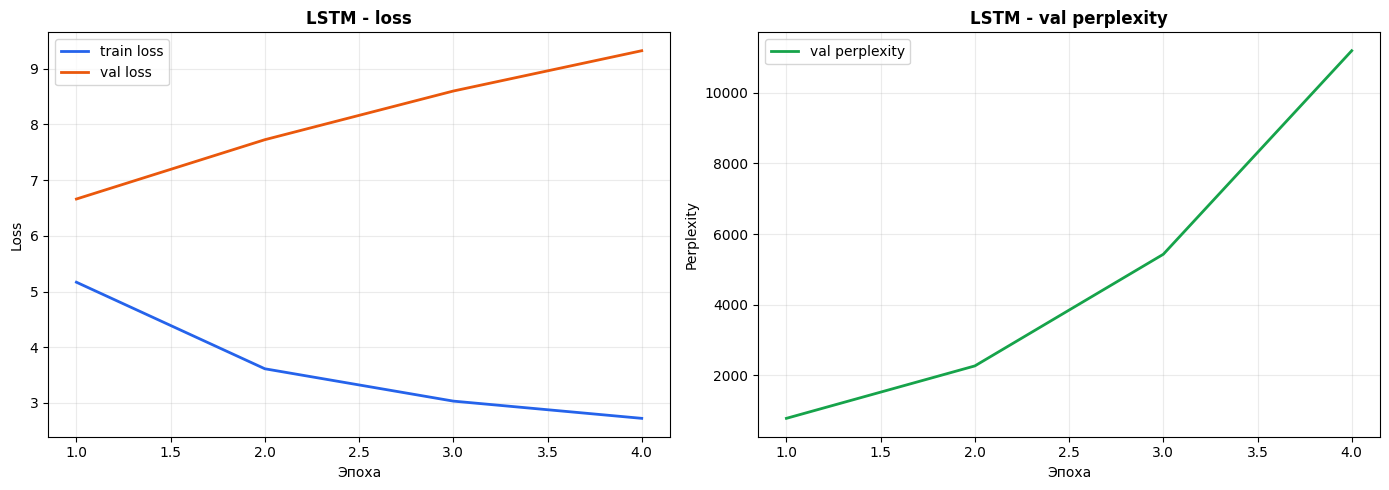

In [24]:
epochs_range = range(1, len(lstm_train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, lstm_train_losses, label='train loss', color='#2563EB', linewidth=2)
axes[0].plot(epochs_range, lstm_val_losses, label='val loss', color='#EA580C', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('LSTM - loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].plot(epochs_range, lstm_val_ppls, label='val perplexity', color='#16A34A', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('LSTM - val perplexity', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Выводы по обучению LSTM

- Лучший результат на validation: Val PPL около 781 (1-я эпоха), Test PPL около 821.
- Train loss падает на всех эпохах, Val PPL растет после 1-й эпохи - признак переобучения.
- Early stopping и сохранение лучших весов по Val PPL оправданы: в финальной модели веса с 1-й эпохи.
- Среднее время эпохи на GPU (T4) около 26 минут.


## Этап 3. Эксперимент: GRU vs LSTM

In [25]:
GRU_CKPT = CHECKPOINT_DIR / 'gru_vm_best.pt'

class LanguageModelGRU(nn.Module):
    """Embedding -> GRU -> Linear (те же гиперпараметры, что у LSTM)"""

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.gru(emb)
        logits = self.fc(out)
        return logits

In [26]:
gru_model = LanguageModelGRU(
    vocab_size=vocab.vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_idx=vocab.pad_idx,
).to(device_rnn)

gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=LR)

print(f'GRU параметров: {count_parameters(gru_model):,}')
print(f'LSTM параметров: {count_parameters(lstm_model):,}')

GRU параметров: 15,672,705
LSTM параметров: 15,903,105


In [27]:
gru_train_losses = []
gru_val_losses = []
gru_val_ppls = []
gru_epoch_times = []
best_gru_val_ppl = float('inf')
gru_loaded_from_ckpt = False

if GRU_CKPT.exists():
    ckpt = torch.load(GRU_CKPT, map_location=device_rnn, weights_only=False)
    gru_model.load_state_dict(ckpt['model_state'])
    gru_train_losses = ckpt['train_losses']
    gru_val_losses = ckpt['val_losses']
    gru_val_ppls = ckpt['val_ppls']
    gru_epoch_times = ckpt['epoch_times']
    best_gru_val_ppl = ckpt['best_val_ppl']
    gru_loaded_from_ckpt = True
    print(f'Загружен чекпоинт: {GRU_CKPT} - обучение пропущено')
    print(f'Лучший Val PPL из файла: {best_gru_val_ppl:.2f}')
else:
    patience_counter = 0
    best_gru_state = None

    for epoch in range(MAX_EPOCHS):
        gru_model.train()
        epoch_start = time.time()
        train_loss = 0.0

        for x_batch, y_batch in tqdm(train_loader, desc=f'GRU Epoch {epoch + 1}/{MAX_EPOCHS}'):
            x_batch = x_batch.to(device_rnn)
            y_batch = y_batch.to(device_rnn)

            gru_optimizer.zero_grad()
            logits = gru_model(x_batch)
            loss = criterion(logits.view(-1, logits.size(-1)), y_batch.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(gru_model.parameters(), CLIP_NORM)
            gru_optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss, val_ppl = evaluate_lm(gru_model, val_loader, criterion, device_rnn)
        epoch_time = time.time() - epoch_start

        gru_train_losses.append(train_loss)
        gru_val_losses.append(val_loss)
        gru_val_ppls.append(val_ppl)
        gru_epoch_times.append(epoch_time)

        print(
            f'Epoch {epoch + 1} | Train Loss: {train_loss:.4f} | '
            f'Val Loss: {val_loss:.4f} | Val PPL: {val_ppl:.2f} | Time: {epoch_time:.1f}s'
        )

        if val_ppl < best_gru_val_ppl:
            best_gru_val_ppl = val_ppl
            patience_counter = 0
            best_gru_state = {k: v.cpu().clone() for k, v in gru_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping на эпохе {epoch + 1}')
                break

    if best_gru_state is not None:
        gru_model.load_state_dict(best_gru_state)

Загружен чекпоинт: checkpoints/gru_vm_best.pt - обучение пропущено
Лучший Val PPL из файла: 1016.35


In [28]:
gru_test_loss, gru_test_ppl = evaluate_lm(gru_model, test_loader, criterion, device_rnn)
gru_num_params = count_parameters(gru_model)
gru_avg_epoch_time = np.mean(gru_epoch_times) if gru_epoch_times else 0.0

print(f'Лучший Val PPL: {best_gru_val_ppl:.2f}')
print(f'Test Loss: {gru_test_loss:.4f} | Test PPL: {gru_test_ppl:.2f}')
print(f'Параметров: {gru_num_params:,} | Среднее время эпохи: {gru_avg_epoch_time:.1f}s')

if not gru_loaded_from_ckpt:
    torch.save(
        {
            'model_state': gru_model.state_dict(),
            'train_losses': gru_train_losses,
            'val_losses': gru_val_losses,
            'val_ppls': gru_val_ppls,
            'epoch_times': gru_epoch_times,
            'best_val_ppl': best_gru_val_ppl,
            'test_loss': gru_test_loss,
            'test_ppl': gru_test_ppl,
            'hyperparams': {
                'embedding_dim': EMBEDDING_DIM,
                'hidden_dim': HIDDEN_DIM,
                'num_layers': NUM_LAYERS,
                'lr': LR,
                'seq_len': SEQ_LEN,
                'batch_size': BATCH_SIZE,
            },
        },
        GRU_CKPT,
    )
    print(f'Чекпоинт сохранен: {GRU_CKPT}')

Лучший Val PPL: 1016.35
Test Loss: 6.9062 | Test PPL: 998.40
Параметров: 15,672,705 | Среднее время эпохи: 1551.0s


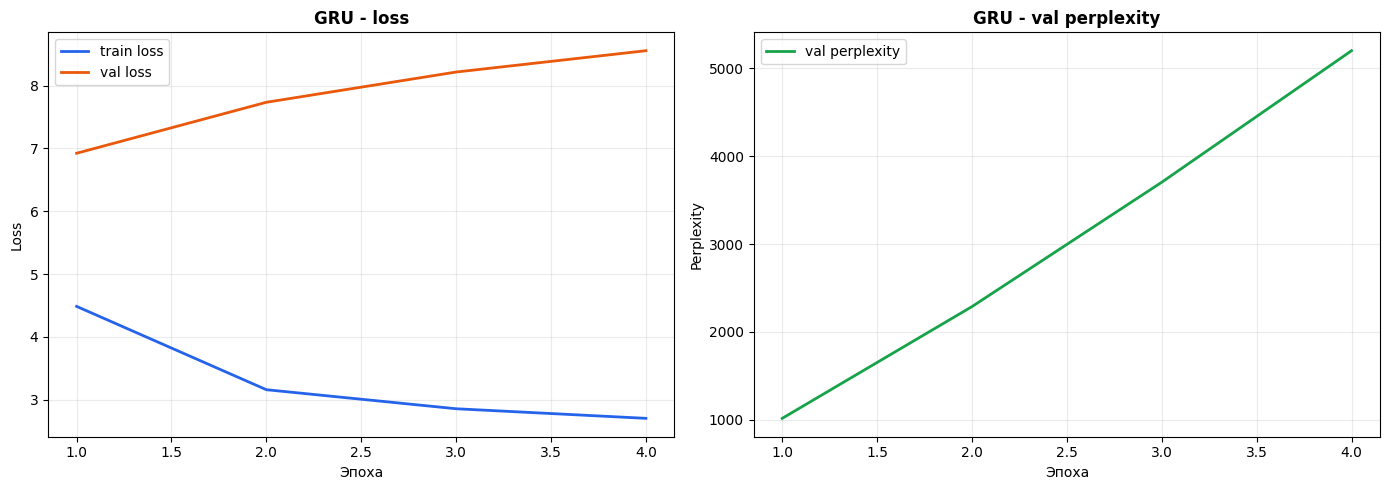

In [29]:
epochs_range = range(1, len(gru_train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, gru_train_losses, label='train loss', color='#2563EB', linewidth=2)
axes[0].plot(epochs_range, gru_val_losses, label='val loss', color='#EA580C', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('GRU - loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].plot(epochs_range, gru_val_ppls, label='val perplexity', color='#16A34A', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('GRU - val perplexity', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [30]:
print('Сравнение LSTM vs GRU')
print('=' * 72)
print(f"{'Модель':<8} | {'Параметры':>12} | {'Val PPL':>10} | {'Test PPL':>10} | {'Время/эпоха':>12}")
print('-' * 72)
print(
    f"{'LSTM':<8} | {lstm_num_params:>12,} | {best_val_ppl:>10.2f} | "
    f"{lstm_test_ppl:>10.2f} | {lstm_avg_epoch_time:>10.1f}s"
)
print(
    f"{'GRU':<8} | {gru_num_params:>12,} | {best_gru_val_ppl:>10.2f} | "
    f"{gru_test_ppl:>10.2f} | {gru_avg_epoch_time:>10.1f}s"
)
print('=' * 72)


Сравнение LSTM vs GRU
Модель   |    Параметры |    Val PPL |   Test PPL |  Время/эпоха
------------------------------------------------------------------------
LSTM     |   15,903,105 |     781.12 |     820.52 |     1578.1s
GRU      |   15,672,705 |    1016.35 |     998.40 |     1551.0s


In [31]:
if best_gru_val_ppl < best_val_ppl:
    print('По val perplexity лучше GRU')
elif best_gru_val_ppl > best_val_ppl:
    print('По val perplexity лучше LSTM')
else:
    print('Val perplexity у LSTM и GRU совпала')

if gru_num_params < lstm_num_params:
    print(f'GRU компактнее на {lstm_num_params - gru_num_params:,} параметров')
if gru_avg_epoch_time < lstm_avg_epoch_time:
    print(f'GRU быстрее на {lstm_avg_epoch_time - gru_avg_epoch_time:.1f}s за эпоху')
elif gru_avg_epoch_time > lstm_avg_epoch_time:
    print(f'LSTM быстрее на {gru_avg_epoch_time - lstm_avg_epoch_time:.1f}s за эпоху')

По val perplexity лучше LSTM
GRU компактнее на 230,400 параметров
GRU быстрее на 27.1s за эпоху


### Выводы: GRU vs LSTM

- По Val/Test PPL лучше LSTM (781 / 821 против 1016 / 998 у GRU при тех же гиперпараметрах).
- GRU легче примерно на 230k параметров и чуть быстрее на эпоху.
- Для продакшена на ограниченных ресурсах GRU можно рассматривать как более легкую альтернативу, если качество LSTM избыточно.


## Этап 4. Оценка distilgpt2

In [32]:
# !pip install transformers

In [33]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

model_name = 'distilgpt2'
gpt2_tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
gpt2_model = GPT2LMHeadModel.from_pretrained(model_name).to(device_gpt)
gpt2_model.eval()

gpt2_num_params = count_parameters(gpt2_model)
print(f'Модель: {model_name}')
print(f'Параметров: {gpt2_num_params:,}')
print(f'Устройство: {device_gpt}')

Модель: distilgpt2
Параметров: 81,912,576
Устройство: mps


In [34]:
def evaluate_distilgpt2_ppl(model, tokenizer, lines, device, max_length=512, stride=256):
    """Perplexity на тестовой выборке (скользящее окно)"""
    model.eval()
    text = '\n'.join(lines)
    encodings = tokenizer(text, return_tensors='pt')
    seq_len = encodings.input_ids.size(1)

    nlls = []
    prev_end_loc = 0

    for begin_loc in tqdm(range(0, seq_len, stride), desc='distilgpt2 PPL'):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100

        with torch.no_grad():
            loss = model(input_ids, labels=target_ids).loss

        nlls.append(loss)
        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    ppl = torch.exp(torch.stack(nlls).mean()).item()
    avg_loss = torch.stack(nlls).mean().item()
    return avg_loss, ppl

In [35]:
gpt2_test_loss, gpt2_test_ppl = evaluate_distilgpt2_ppl(
    gpt2_model, gpt2_tokenizer, test_lines, device_gpt,
)

print(f'Test Loss: {gpt2_test_loss:.4f}')
print(f'Test PPL: {gpt2_test_ppl:.2f}')
print('\nВажно: perplexity distilgpt2 и LSTM/GRU напрямую не сравнимы (разные токенизаторы и словари)')

Token indices sequence length is longer than the specified maximum sequence length for this model (249102 > 1024). Running this sequence through the model will result in indexing errors
distilgpt2 PPL: 100%|█████████▉| 972/974 [00:26<00:00, 37.26it/s]

Test Loss: 4.3791
Test PPL: 79.77

Важно: perplexity distilgpt2 и LSTM/GRU напрямую не сравнимы (разные токенизаторы и словари)


### Выводы по distilgpt2

- Модель не обучалась в проекте: использованы предобученные веса с Hugging Face.
- Test PPL около 80 (subword-токенизация, другая метрика относительно LSTM/GRU).
- На коротких контекстах модель выдает осмысленные продолжения (United, be, very и т.д.).
- Для реального автодополнения в продукте предобученный трансформер предпочтительнее по качеству и скорости инференса.


In [36]:
def predict_next_word_gpt2(model, tokenizer, context, device):
    """Предсказание следующего токена (greedy)"""
    inputs = tokenizer(context, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    next_id = logits[0, -1].argmax().item()
    return tokenizer.decode([next_id])

example_contexts = [
    'the president of the',
    'i want to',
    'the weather today is',
    'new york is a',
]

print('Примеры предсказаний distilgpt2 (следующее слово):')
for ctx in example_contexts:
    pred = predict_next_word_gpt2(gpt2_model, gpt2_tokenizer, ctx, device_gpt)
    print(f'  "{ctx}" -> "{pred.strip()}"')

Примеры предсказаний distilgpt2 (следующее слово):
  "the president of the" -> "United"
  "i want to" -> "be"
  "the weather today is" -> "a"
  "new york is a" -> "very"


In [37]:
# генерация продолжения 
prompt = 'the president of the'
inputs = gpt2_tokenizer(prompt, return_tensors='pt').to(device_gpt)

with torch.no_grad():
    output_ids = gpt2_model.generate(
        **inputs,
        max_new_tokens=15,
        do_sample=True,
        top_p=0.95,
        temperature=0.8,
    )

generated = gpt2_tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(f'Промпт: {prompt}')
print(f'Сгенерировано: {generated}')

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Промпт: the president of the
Сгенерировано: the president of the United States of America, David K. Bannon, has said that he has


## Этап 5. Сравнение и выводы


In [38]:
print('Сводная таблица результатов')
print('=' * 82)
print(f"{'Модель':<12} | {'Параметры':>12} | {'Val PPL':>10} | {'Test PPL':>10} | {'Время/эпоха':>12}")
print('-' * 82)
print(
    f"{'LSTM':<12} | {lstm_num_params:>12,} | {best_val_ppl:>10.2f} | "
    f"{lstm_test_ppl:>10.2f} | {lstm_avg_epoch_time:>10.1f}s"
)
print(
    f"{'GRU':<12} | {gru_num_params:>12,} | {best_gru_val_ppl:>10.2f} | "
    f"{gru_test_ppl:>10.2f} | {gru_avg_epoch_time:>10.1f}s"
)
print(
    f"{'distilgpt2':<12} | {gpt2_num_params:>12,} | {'n/a':>10} | "
    f"{gpt2_test_ppl:>10.2f} | {'n/a':>12}"
)
print('=' * 82)
print('Val PPL для distilgpt2 не считался: модель предобучена, другой токенизатор')
print('Числа LSTM/GRU и distilgpt2 по PPL сравниваются только качественно.')


Сводная таблица результатов
Модель       |    Параметры |    Val PPL |   Test PPL |  Время/эпоха
----------------------------------------------------------------------------------
LSTM         |   15,903,105 |     781.12 |     820.52 |     1578.1s
GRU          |   15,672,705 |    1016.35 |     998.40 |     1551.0s
distilgpt2   |   81,912,576 |        n/a |      79.77 |          n/a
Val PPL для distilgpt2 не считался: модель предобучена, другой токенизатор
Числа LSTM/GRU и distilgpt2 по PPL сравниваются только качественно.


In [39]:
def predict_next_word_rnn(model, vocab, context, device, seq_len=SEQ_LEN):
    # предсказание следующего слова для LSTM/GRU
    words = clean_string(context).split()
    if not words:
        return '<unk>'
    ids = [vocab.word2idx.get(w, vocab.unk_idx) for w in words]
    chunk = ids[-(seq_len - 1):]
    x = torch.tensor([chunk], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
    next_id = logits[0, -1].argmax().item()
    return vocab.idx2word.get(next_id, '<unk>')

contexts = [
    'the president of the',
    'i want to',
    'the weather today is',
    'new york is a',
    'he was born in',
    'the game was',
    'they went to the',
]

print('Предсказания на одних и тех же контекстах')
print('=' * 72)
for ctx in contexts:
    lstm_pred = predict_next_word_rnn(lstm_model, vocab, ctx, device_rnn)
    gru_pred = predict_next_word_rnn(gru_model, vocab, ctx, device_rnn)
    gpt_pred = predict_next_word_gpt2(gpt2_model, gpt2_tokenizer, ctx, device_gpt).strip()
    print(f'Контекст: "{ctx}"')
    print(f'  LSTM:       {lstm_pred}')
    print(f'  GRU:        {gru_pred}')
    print(f'  distilgpt2: {gpt_pred}')
    print()


Предсказания на одних и тех же контекстах
Контекст: "the president of the"
  LSTM:       federative
  GRU:        united
  distilgpt2: United

Контекст: "i want to"
  LSTM:       be
  GRU:        do
  distilgpt2: be

Контекст: "the weather today is"
  LSTM:       the
  GRU:        also
  distilgpt2: a

Контекст: "new york is a"
  LSTM:       reference
  GRU:        song
  distilgpt2: very

Контекст: "he was born in"
  LSTM:       <unk>
  GRU:        the
  distilgpt2: the

Контекст: "the game was"
  LSTM:       released
  GRU:        released
  distilgpt2: a

Контекст: "they went to the"
  LSTM:       new
  GRU:        final
  distilgpt2: hospital



### Выводы и рекомендации для PM

Какая модель лучше

- По метрикам на нашем датасете лучше distilgpt2 (низкий test PPL, осмысленные продолжения без дообучения).
- Среди обученных с нуля RNN лучше LSTM по Val/Test perplexity; GRU чуть легче и быстрее, но качество ниже.

Рекомендации для продукта

1. MVP / быстрый запуск: distilgpt2 или аналогичный предобученный трансформер - минимум разработки, лучшее качество текста.
2. Офлайн / свой словарь / полный контроль: LSTM с early stopping (1-2 эпохи), если нельзя использовать внешние модели.
3. Мобильные / edge-сценарии: GRU как компромисс между размером и качеством, но нужна калибровка на продуктовых текстах.
4. Метрики: для бизнеса важнее A/B-тест автодополнения в интерфейсе, а не только perplexity; PPL разных токенизаторов не смешивать в одну KPI.

Ограничения проекта

- Обучение RNN на CPU занимает часы; для экспериментов нужен GPU.
- WikiText-2 - энциклопедия; иначе говоря качество всех моделей может быть ниже.
